<a href="https://colab.research.google.com/github/CienciaDatosUdea/002_EstudiantesAprendizajeEstadistico/blob/main/semestre2026-1/Laboratorios/Laboratorio_02_pandas_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Lab 2: Estadística Descriptiva Básica 2

## Series de tiempo

El siguiente [dataset](https://raw.githubusercontent.com/hernansalinas/Curso_aprendizaje_estadistico/main/datasets/Pandas_data_historical_dataEURUSD.csv) contiene información del precio del eur/usd  desde el 05/07/2022/ hasta el 12/05/2023 con periodicidad de una hora. El data frame contiene el precio de apertura, cierrre, valor más bajo cotizado, valor más alto cotizado, volumen, spread etc. Para este dataset, realizar lo siguiente:


1. Leer el dataset desde el github.
2. Definir como indice la columna time.
3. Obtenga información del data frame.

4. Determine si hay null, nan en el data frame.

5. Emplea la notacion Pascal Case y trabaja solo con la columa del precio de cierre del eur/usd.  

6. Ahora vamos a determinar cual es la mejor distribución estadística que se ajusta a la diferencia del precio de cierre cada hora, para ello realizamos lo siguiente:
- Determine la diferencia de precio entre horas, agregue una nueva columna llamada DiffPrice, en este punto tu dataframe debe tener solo dos columnas Close, DiffPrice y el indice debe ser el tiempo.
- Para la nueva columna construya un histograma de los datos.
- Determine la mejor distribucion estadística que se ajusta al histograma anterior, para ello puede emplear lo siguente:


https://pypi.org/project/fitter/

```python


from fitter import Fitter, get_common_distributions, get_distributions

f = Fitter(data,
           distributions=['gamma',
                          'lognorm',
                          "beta",
                          "burr",
                          "norm"])
f.fit()
f.summary()
#Indentificamos la mejor distribucion con el error cuadratico medio
f.get_best(method = 'sumsquare_error')
#Indentificamos parametros de la distrubicion beta
f.fitted_param["beta"]

```

Con el metodo get_distributions(), podemos ver todas las distribuciones estadisticas de la libreria. Ajusta a la mejor.  Puede consultar [esta](https://medium.com/the-researchers-guide/finding-the-best-distribution-that-fits-your-data-using-pythons-fitter-library-319a5a0972e9)  página si desea ver un ejemplo.


7. Para el data frame, seleccionemos solo los datos del 2023.

8. El comando groupby permite agrupar los datos con la periodicidad deseada: 1 dias, 2 dias, 1 mes etc. Determina el promedio con una periodicidad de 15 dias, con periodidicidad de 1 semana, y una periodicidad de 1 mes

```python
  df.groupby(pd.Grouper(key='time', freq='15D')).mean()
```

9. Para los datos asociados a los meses de 2023, construya un histograma para cada mes.  Para ello puedo emplear el metodo groupby. Notetese que si no  realiza una operación después de aplicar el metodo grouby, podrias iterar sobre dicho objeto, por ejemplo:

```python
q=df.groupby(pd.Grouper(key='time', freq='15D'))

for name, group in q:
  print(name, group)
```


In [6]:
import pandas as pd
import matplotlib.pyplot as plt

#1. Leer el dataset desde el github.

url = "https://raw.githubusercontent.com/hernansalinas/Curso_aprendizaje_estadistico/main/datasets/Pandas_data_historical_dataEURUSD.csv"
data = pd.read_csv(url)

#2. Definir como indice la columna time.

data.set_index('time', inplace=True)

#3 Obtenga información del data frame.
Info = data.info() , data.describe() 
print(Info)             

data.head()

<class 'pandas.DataFrame'>
Index: 5000 entries, 2022-07-25 13:00:00 to 2023-05-12 23:00:00
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          5000 non-null   int64  
 1   open                5000 non-null   float64
 2   high                5000 non-null   float64
 3   low                 5000 non-null   float64
 4   close               5000 non-null   float64
 5   tick_volume         5000 non-null   int64  
 6   spread              5000 non-null   int64  
 7   real_volume         5000 non-null   int64  
 8   MeanCloseOpen       5000 non-null   float64
 9   Diff_Close          5000 non-null   float64
 10  Diff_Open           5000 non-null   float64
 11  Diff_MeanCloseOpen  5000 non-null   float64
dtypes: float64(8), int64(4)
memory usage: 507.8+ KB
(None,         Unnamed: 0         open         high          low        close  \
count  5000.000000  5000.000000  5000.000000  5000.00000

,Unnamed: 0,open,high,low,close,tick_volume,spread,real_volume,MeanCloseOpen,Diff_Close,Diff_Open,Diff_MeanCloseOpen
time,,,,,,,,,,,,
2022-07-25 13:00:00,0,1.02427,1.02430,1.02145,1.02345,3927,8,0,1.023860,-0.00046,-0.00082,-0.000640
2022-07-25 14:00:00,1,1.02345,1.02578,1.02288,1.02299,5344,8,0,1.023220,-0.00046,-0.00082,-0.000640
2022-07-25 15:00:00,2,1.02303,1.02476,1.02230,1.02457,5524,8,0,1.023800,0.00158,-0.00042,0.000580
2022-07-25 16:00:00,3,1.02454,1.02548,1.02355,1.02485,5234,8,0,1.024695,0.00028,0.00151,0.000895
2022-07-25 17:00:00,4,1.02485,1.02514,1.02030,1.02181,9031,7,0,1.023330,-0.00304,0.00031,-0.001365


In [5]:
#4. Determine si hay null, nan en el data frame.

nulos = data.isnull().sum()
print("Valores nulos por columna:\n", nulos)

Valores nulos por columna:
 Unnamed: 0            0
open                  0
high                  0
low                   0
close                 0
tick_volume           0
spread                0
real_volume           0
MeanCloseOpen         0
Diff_Close            0
Diff_Open             0
Diff_MeanCloseOpen    0
dtype: int64


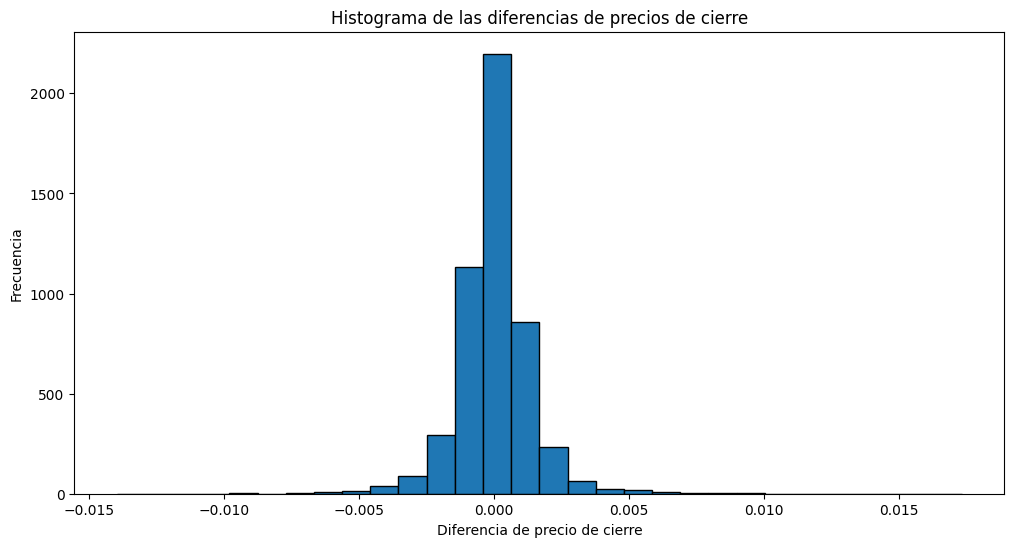

In [19]:
#5. Emplea la notacion Pascal Case y trabaja solo con la columa del precio de cierre del eur/usd.
PrecioCierre = data[['close']].copy()
PrecioCierre = PrecioCierre.rename(columns={'close': 'Close'})
PrecioCierre["DiffPrice"] = PrecioCierre["Close"].diff()
#6
plt.figure(figsize=(12, 6))
plt.hist(PrecioCierre["DiffPrice"].dropna(), bins=30, edgecolor='black')
plt.title("Histograma de las diferencias de precios de cierre")
plt.xlabel("Diferencia de precio de cierre")
plt.ylabel("Frecuencia")
plt.show()

{'lognorm': {'s': np.float64(0.009509964461157715), 'loc': np.float64(-0.1471693008245066), 'scale': np.float64(0.14717494036949658)}}
Mejor distribución: lognorm
Parámetros: (np.float64(0.009509964461157715), np.float64(-0.1471693008245066), np.float64(0.14717494036949658))


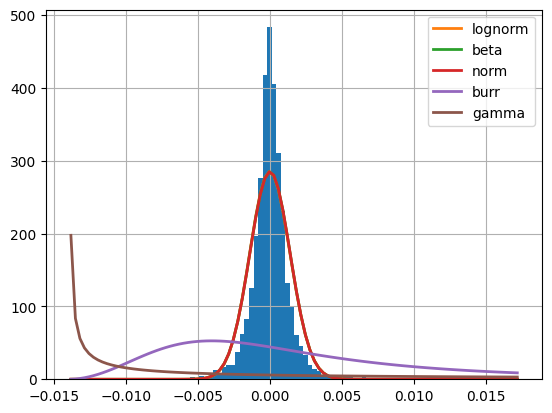

In [22]:
#6
from fitter import Fitter, get_common_distributions, get_distributions

f = Fitter(PrecioCierre["DiffPrice"].dropna(),
           distributions=['gamma',
                          'lognorm',
                          "beta",
                          "burr",
                          "norm"])
f.fit()
f.summary()
#Indentificamos la mejor distribucion con el error cuadratico medio
BestDist = f.get_best(method='sumsquare_error')
print(BestDist)
DistName = list(BestDist.keys())[0]
Params = f.fitted_param[DistName]

print("Mejor distribución:", DistName)
print("Parámetros:", Params)

In [25]:
#7. Para el data frame, seleccionemos solo los datos del 2023.

PrecioCierre.index = pd.to_datetime(PrecioCierre.index)
Data2023 = PrecioCierre.loc['2023']
Data2023

,Close,DiffPrice
time,,
2023-01-02 00:00:00,1.06796,-0.00200
2023-01-02 01:00:00,1.06965,0.00169
2023-01-02 02:00:00,1.07058,0.00093
2023-01-02 03:00:00,1.06896,-0.00162
2023-01-02 04:00:00,1.06880,-0.00016
...,...,...
2023-05-12 19:00:00,1.08514,-0.00038
2023-05-12 20:00:00,1.08546,0.00032
2023-05-12 21:00:00,1.08531,-0.00015


In [38]:
#8. El comando groupby permite agrupar los datos con la periodicidad deseada: 1 dias, 2 dias, 1 mes etc. 
# Determina el promedio con una periodicidad de 15 dias, con periodidicidad de 1 semana, y una periodicidad 
# de 1 mes

Promedio15Dias = Data2023.resample('15D').mean()
Promedio1Semana = Data2023.resample('W').mean()
Promedio1Mes = Data2023.resample('ME').mean()

print("Promedio cada 15 días:\n", Promedio15Dias)
print("\nPromedio cada semana:\n", Promedio1Semana)
print("\nPromedio cada mes:\n", Promedio1Mes)

Promedio cada 15 días:
                Close  DiffPrice
time                           
2023-01-02  1.069361   0.000047
2023-01-17  1.085565   0.000015
2023-02-01  1.077679  -0.000066
2023-02-16  1.063150  -0.000034
2023-03-03  1.063186   0.000026
2023-03-18  1.080936   0.000074
2023-04-02  1.093090   0.000063
2023-04-17  1.099084  -0.000006
2023-05-02  1.098889  -0.000059

Promedio cada semana:
                Close  DiffPrice
time                           
2023-01-08  1.059972  -0.000047
2023-01-15  1.076002   0.000156
2023-01-22  1.082041   0.000020
2023-01-29  1.088414   0.000010
2023-02-05  1.089281  -0.000062
2023-02-12  1.073363  -0.000097
2023-02-19  1.069648   0.000014
2023-02-26  1.063374  -0.000124
2023-03-05  1.060854   0.000073
2023-03-12  1.060234   0.000004
2023-03-19  1.066518   0.000022
2023-03-26  1.077974   0.000079
2023-04-02  1.083874   0.000070
2023-04-09  1.090534   0.000047
2023-04-16  1.095646   0.000080
2023-04-23  1.096117  -0.000004
2023-04-30  1.101908   0

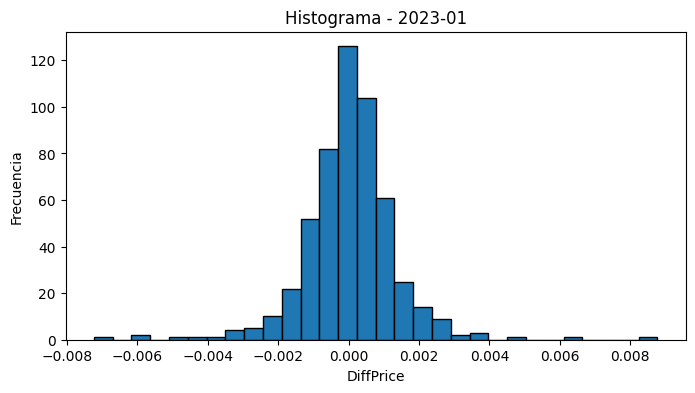

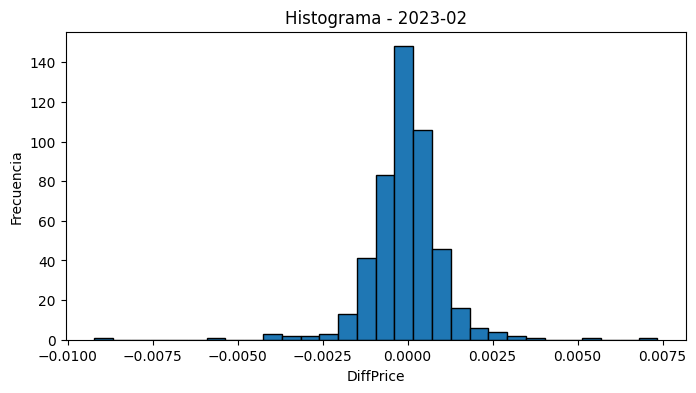

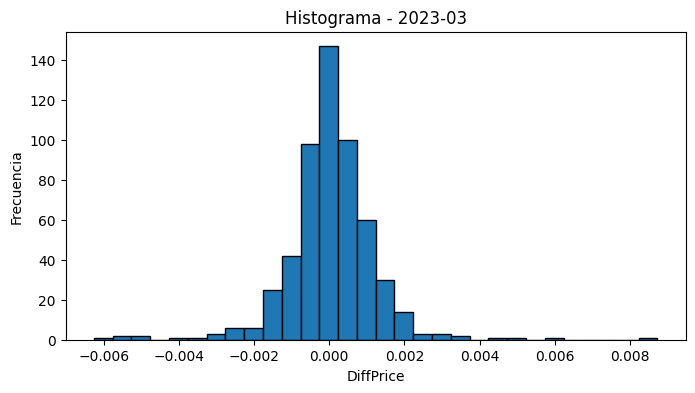

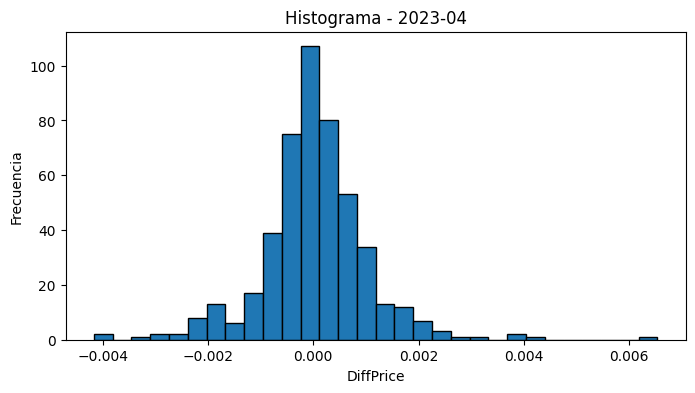

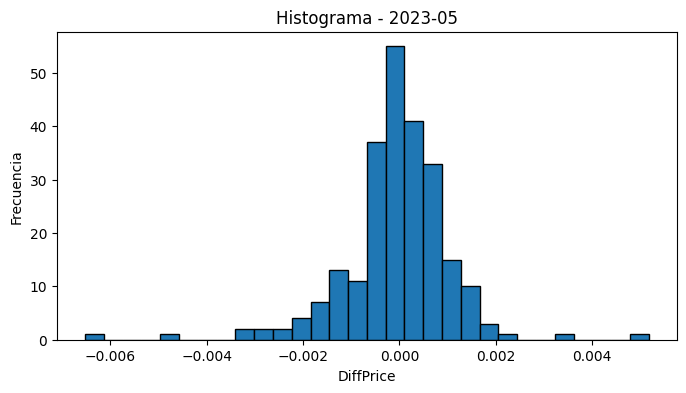

In [ ]:
#9 Para los datos asociados a los meses de 2023,
# construya un histograma para cada mes. Para ello puedo emplear el metodo groupby. 

GruposMes = Data2023.groupby(pd.Grouper(freq='ME'))

for Nombre, Grupo in GruposMes:
    
    plt.figure(figsize=(8, 4))
    
    plt.hist(Grupo["DiffPrice"].dropna(), bins=30, edgecolor='black')
    
    plt.title(f"Histograma - {Nombre.strftime('%Y-%m')}")
    plt.xlabel("DiffPrice")
    plt.ylabel("Frecuencia")
    
    plt.show()

## Análisis de datos con pandas. 

Para el siguiente [dataset](https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+%28Diagnostic%29) realizar lo siguiente:


1. Leer los datos desde una página web.

2. Renombrar las columnas en formato PascalCase.

3. Utilizar los métodos `head()`, `tail()`, `describe()` e `info()` para obtener información sobre el `DataFrame`.

4. Contabilizar la cantidad de valores nulos (`null` o `NaN`) en el `DataFrame`.
   Si se encuentran valores nulos, ¿qué estrategia propondrías para reemplazarlos?

5. Identificar los valores únicos en la columna `target` que representan las etiquetas B y M (Benigno y Maligno, respectivamente).
   Utiliza el método `unique()` para mostrar estos valores.

6. Realizar un conteo de los casos etiquetados como B y M utilizando la librería `seaborn` y el método `countplot()`:

```python
import seaborn as sns
sns.countplot?
```

7. Agregar una nueva columna llamada `DiagnosisNumeric` donde se asigna el valor 0 a la etiqueta B (Benigno) y el valor 1 a la etiqueta M (Maligno).


8. Normalizar cada columna respecto a su media y desviación estándar utilizando la fórmula:  
   `(x - mean(x)) / std(x)`

9. Agrupar características similares y calcular su promedio.
   Para las siguientes características:

```python
['RadiusMean', 'TextureMean', 'PerimeterMean', 'AreaMean', 'SmoothnessMean', 'CompactnessMean', 'ConcavityMean', 'ConcavePointsMean', "SymmetryMean", "FractalDimensionMean"]
```

Usa expresiones regulares para identificar patrones comunes, como `radius1`, `radius2`,`radius3`, etc., y calcular los promedios. Por ejemplo:

```python
re.match(r'^[a-zA-Z_]+', "holamundo12341").group(0)
```

También puedes utilizar el método `startswith()` para buscar estos patrones en los nombres de las columnas.


10. Crear un gráfico donde se muestre el histograma de la columna `RadiusMean` separado por las etiquetas B y M, utilizando colores diferentes (naranja y azul, respectivamente) para cada diagnóstico.

11. Generar gráficos de violín para múltiples características.
   Para las columnas:

   - `RadiusMean`
   - `TextureMean`
   - `PerimeterMean`
   - `AreaMean`
   - `SmoothnessMean`
   - `CompactnessMean`
   - `ConcavityMean`
   - `ConcavePointsMean`
   - `Symmetry3`
   - `FractalDimension3`

   Realiza un gráfico múltiple tipo violín, como en el siguiente ejemplo:

```python
data = pd.melt(df.iloc[:, 0:10], id_vars="Diagnosis", var_name="features", value_name="value")
sns.violinplot(x="features", y="value", hue="Diagnosis", data=data, split=True, inner="quart")
plt.xticks(rotation=45)
```


12.  Determinar y eliminar los valores atípicos (`outliers`) en la columna `RadiusMean`.

Para identificarlos, construye un gráfico tipo `boxplot`:

```python
df.boxplot(column="RadiusMean", by='Diagnosis', sym='k.', figsize=(18,6))
```

Usa el rango intercuartílico (IQR) para definir los outliers. Los valores fuera del rango [Q1 - 1.5 * IQR, Q3 + 1.5 * IQR] se consideran outliers. Ejemplo de cómo eliminar estos valores:

```python
Q1 = df['edad'].quantile(0.25)
Q3 = df['edad'].quantile(0.75)
IQR = Q3 - Q1
df = df[~((df['edad'] < (Q1 - 1.5 * IQR)) | (df['edad'] > (Q3 + 1.5 * IQR)))]
```

Otra alternativa es utilizar el puntaje Z para detectar `outliers`:

```python 
df = df[(np.abs(stats.zscore(df['edad'])) < 3)]
```



13. Encontrar la matrix de correlación, emplear el metodo corr(), dentro de seaborn buscar el metodo heatmap() para realizar un grafico de la matrix de correlación.

14. ¿Que otro tipo de gráficos pueden ser realizados para entender mejor los datos?



In [ ]:
import pandas as pd

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data"

# El archivo no tiene encabezado, hay que definirlo manualmente (hecho con ayuda de Claude)
columnas = [
    "id", "diagnosis",
    "radius_mean", "texture_mean", "perimeter_mean", "area_mean",
    "smoothness_mean", "compactness_mean", "concavity_mean", "concave_points_mean",
    "symmetry_mean", "fractal_dimension_mean",
    "radius_se", "texture_se", "perimeter_se", "area_se",
    "smoothness_se", "compactness_se", "concavity_se", "concave_points_se",
    "symmetry_se", "fractal_dimension_se",
    "radius_worst", "texture_worst", "perimeter_worst", "area_worst",
    "smoothness_worst", "compactness_worst", "concavity_worst", "concave_points_worst",
    "symmetry_worst", "fractal_dimension_worst"
]

df = pd.read_csv(url, header=None, names=columnas)

print(df.shape)       # (569, 32)
print(df.head())
print(df["diagnosis"].value_counts())  # B=357, M=212



(569, 32)
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave_points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture_worst  perimeter_worst

In [50]:
# Convertir columnas a PascalCase
df.columns = [col.replace("_", " ").title().replace(" ", "") for col in df.columns]

print(df.columns.tolist())
df.head()

['Id', 'Diagnosis', 'Radiusmean', 'Texturemean', 'Perimetermean', 'Areamean', 'Smoothnessmean', 'Compactnessmean', 'Concavitymean', 'Concavepointsmean', 'Symmetrymean', 'Fractaldimensionmean', 'Radiusse', 'Texturese', 'Perimeterse', 'Arease', 'Smoothnessse', 'Compactnessse', 'Concavityse', 'Concavepointsse', 'Symmetryse', 'Fractaldimensionse', 'Radiusworst', 'Textureworst', 'Perimeterworst', 'Areaworst', 'Smoothnessworst', 'Compactnessworst', 'Concavityworst', 'Concavepointsworst', 'Symmetryworst', 'Fractaldimensionworst']


,Id,Diagnosis,Radiusmean,Texturemean,Perimetermean,Areamean,Smoothnessmean,Compactnessmean,Concavitymean,Concavepointsmean,...,Radiusworst,Textureworst,Perimeterworst,Areaworst,Smoothnessworst,Compactnessworst,Concavityworst,Concavepointsworst,Symmetryworst,Fractaldimensionworst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [52]:
#3) Utilizar los métodos head(), tail(), describe() e info() para obtener información sobre el DataFrame.
Info = df.head(), df.tail(), df.info() , df.describe()

for i in Info:
    print(i)
    print("--------------------------------------")


<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Id                     569 non-null    int64  
 1   Diagnosis              569 non-null    str    
 2   Radiusmean             569 non-null    float64
 3   Texturemean            569 non-null    float64
 4   Perimetermean          569 non-null    float64
 5   Areamean               569 non-null    float64
 6   Smoothnessmean         569 non-null    float64
 7   Compactnessmean        569 non-null    float64
 8   Concavitymean          569 non-null    float64
 9   Concavepointsmean      569 non-null    float64
 10  Symmetrymean           569 non-null    float64
 11  Fractaldimensionmean   569 non-null    float64
 12  Radiusse               569 non-null    float64
 13  Texturese              569 non-null    float64
 14  Perimeterse            569 non-null    float64
 15  Arease           

In [ ]:
#4. Contabilizar la cantidad de valores nulos (null o NaN) en el DataFrame. Si se encuentran valores nulos, ¿qué estrategia propondrías para reemplazarlos?

nulos = df.isnull().sum()
print("Valores nulos por columna:\n", nulos)

# No hay valores nulos, pero si los hubiera, dependiendo de la cantidad y la importancia de la columna,
#  podríamos considerar estrategias como: 
# - Eliminar las filas con valores nulos
# - Eliminar las columnas con demasiados valores nulos
# - Reemplazar los valores nulos por la media, mediana o moda de la columna
# - Utilizar técnicas de imputación más avanzadas, como regresión o k-NN

Valores nulos por columna:
 Id                       0
Diagnosis                0
Radiusmean               0
Texturemean              0
Perimetermean            0
Areamean                 0
Smoothnessmean           0
Compactnessmean          0
Concavitymean            0
Concavepointsmean        0
Symmetrymean             0
Fractaldimensionmean     0
Radiusse                 0
Texturese                0
Perimeterse              0
Arease                   0
Smoothnessse             0
Compactnessse            0
Concavityse              0
Concavepointsse          0
Symmetryse               0
Fractaldimensionse       0
Radiusworst              0
Textureworst             0
Perimeterworst           0
Areaworst                0
Smoothnessworst          0
Compactnessworst         0
Concavityworst           0
Concavepointsworst       0
Symmetryworst            0
Fractaldimensionworst    0
dtype: int64


In [56]:
# Identificar los valores únicos en la columna target que representan las etiquetas B y M 
# (Benigno y Maligno, respectivamente). Utiliza el método unique() para mostrar estos valores.

ValoresTarget = df['Diagnosis'].unique()
print("Valores únicos en la columna 'Diagnosis':", ValoresTarget)

Valores únicos en la columna 'Diagnosis': <StringArray>
['M', 'B']
Length: 2, dtype: str


Axes(0.125,0.11;0.775x0.77)
Diagnosis
B    357
M    212
Name: count, dtype: int64


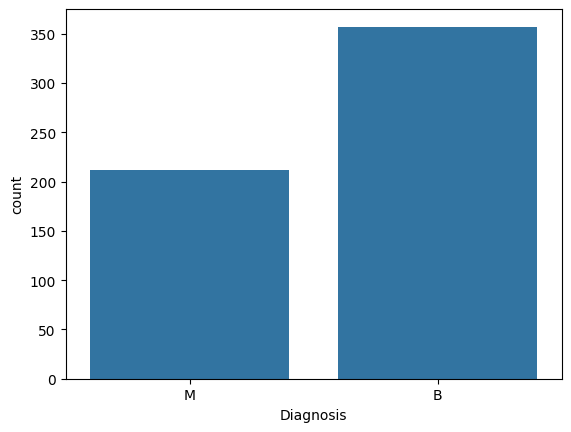

In [61]:
#6) Realizar un conteo de los casos etiquetados como B y M utilizando la librería seaborn y el método countplot():
import seaborn as sns

print(sns.countplot(x='Diagnosis', data=df))
print(df['Diagnosis'].value_counts())

In [62]:
#7) Agregar una nueva columna llamada DiagnosisNumeric donde se asigna el valor 0 a la etiqueta B (Benigno) y el valor 1 a la etiqueta M (Maligno).

df['DiagnosisNumeric'] = df['Diagnosis'].map({'B': 0, 'M': 1})
print(df[['Diagnosis', 'DiagnosisNumeric']].head())

  Diagnosis  DiagnosisNumeric
0         M                 1
1         M                 1
2         M                 1
3         M                 1
4         M                 1


In [68]:
#8) Normalizar cada columna respecto a su media y desviación estándar 

columnas_a_normalizar = df.columns.drop(['Id', 'Diagnosis', 'DiagnosisNumeric'])
dfc = df.copy()  # Crear una copia del DataFrame original para normalizar
for col in columnas_a_normalizar:
    media = df[col].mean()
    desviacion_estandar = df[col].std()
    dfc[col] = (df[col] - media) / desviacion_estandar



In [73]:
#9)
import re

# 1. Extraer raíces únicas
raices = set()
for col in dfc.columns:
    match = re.match(r'^[A-Za-z]+(?=mean|se|worst)', col)
    if match:
        raices.add(match.group(0))

print(raices)
# {'Radius', 'Texture', 'Perimeter', ...}

# 2. Agrupar y calcular promedio
promedios = {}

for raiz in raices:
    columnas_grupo = [col for col in dfc.columns 
                      if re.match(rf'^{raiz}(mean|se|worst)$', col)]
    
    if len(columnas_grupo) > 1:
        promedios[raiz] = dfc[columnas_grupo].mean(axis=1)

# 3. Convertir a DataFrame
df_promedios = pd.DataFrame(promedios)
print(df_promedios.head())

{'Perimeter', 'Concavity', 'Compactness', 'Fractaldimension', 'Radius', 'Texture', 'Concavepoints', 'Smoothness', 'Symmetry', 'Area'}
   Perimeter  Concavity  Compactness  Fractaldimension    Radius   Texture  \
0   2.133644   1.827201     2.403566          1.698454  1.822892 -1.331460   
1   1.160448  -0.203612    -0.536342         -0.228767  1.377122 -0.532558   
2   1.253866   0.809797     0.982746          0.032286  1.438879 -0.115855   
3  -0.185181   1.573617     3.343920          3.960995 -0.241121  0.092354   
4   1.461481   0.936729     0.059090         -0.153272  1.438539 -1.135278   

   Concavepoints  Smoothness  Symmetry      Area  
0       1.828182    0.886604  2.037172  1.822793  
1       0.631241   -0.602112 -0.349009  1.512536  
2       1.804099    0.390527  0.775643  1.397605  
3       1.579444    2.453684  4.544703 -0.533818  
4       1.099685    0.660750 -0.412639  1.411195  


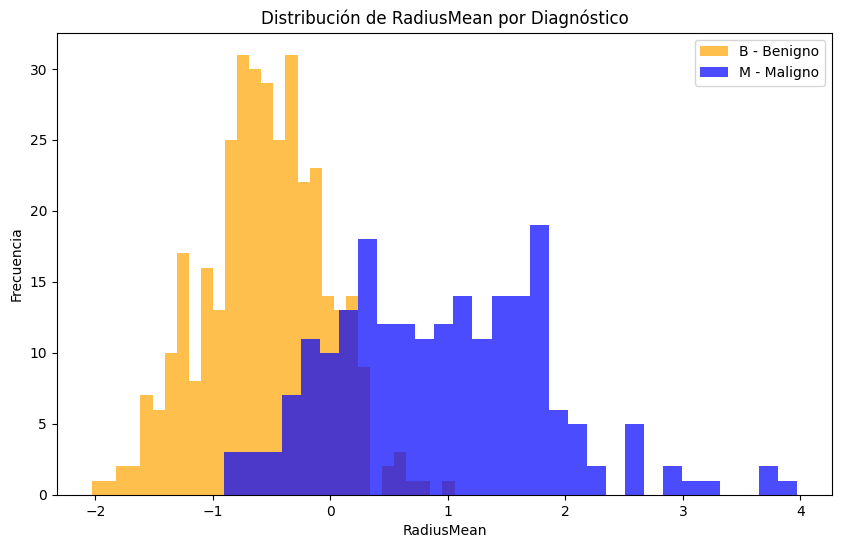

In [74]:
#10) 
# Separar por diagnóstico
benign = dfc[dfc['Diagnosis'] == 'B']['Radiusmean']
malignant = dfc[dfc['Diagnosis'] == 'M']['Radiusmean']

# Crear histograma
plt.figure(figsize=(10, 6))
plt.hist(benign, bins=30, color='orange', alpha=0.7, label='B - Benigno')
plt.hist(malignant, bins=30, color='blue', alpha=0.7, label='M - Maligno')

plt.title('Distribución de RadiusMean por Diagnóstico')
plt.xlabel('RadiusMean')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

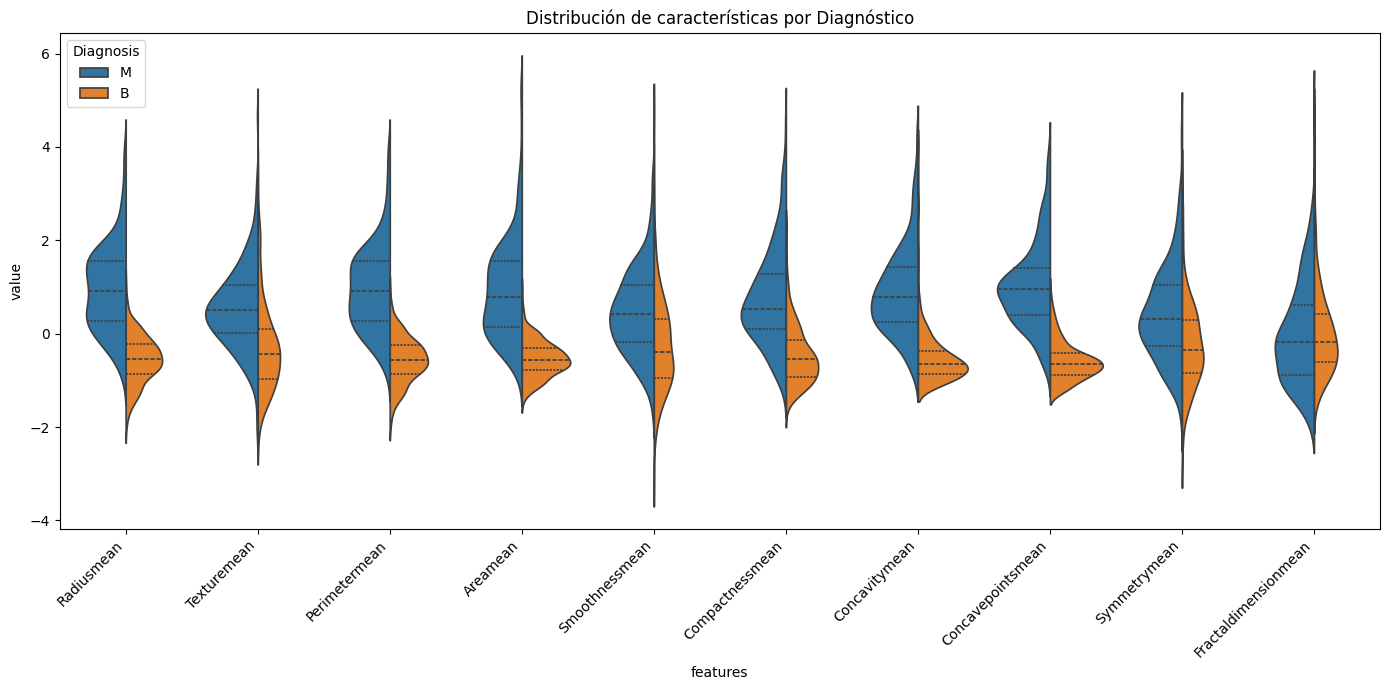

In [75]:
#11) 
# # Columnas a graficar (usando los nombres como quedaron en tu DataFrame)
columnas = ['Diagnosis', 'Radiusmean', 'Texturemean', 'Perimetermean', 'Areamean',
            'Smoothnessmean', 'Compactnessmean', 'Concavitymean', 'Concavepointsmean',
            'Symmetrymean', 'Fractaldimensionmean']

# Transformar a formato largo con melt
data = pd.melt(dfc[columnas], id_vars="Diagnosis", var_name="features", value_name="value")

# Crear gráfico
plt.figure(figsize=(14, 7))
sns.violinplot(x="features", y="value", hue="Diagnosis", data=data, split=True, inner="quart")

plt.title('Distribución de características por Diagnóstico')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

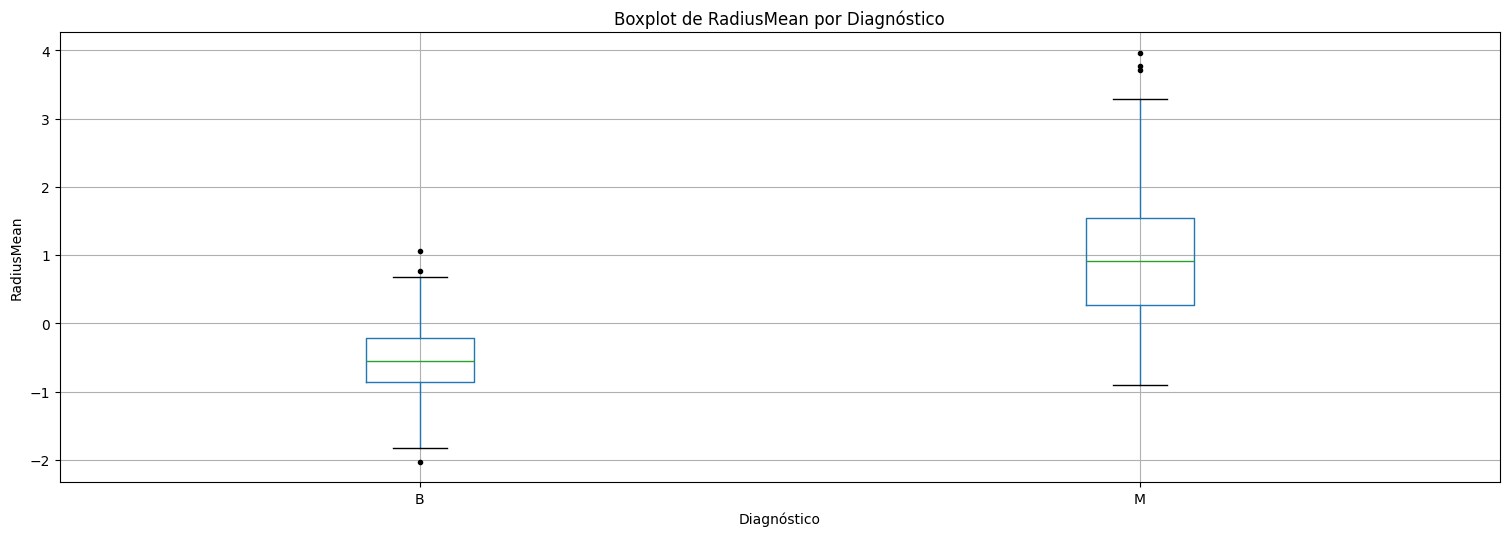

In [76]:
#12) 
dfc.boxplot(column="Radiusmean", by='Diagnosis', sym='k.', figsize=(18, 6))
plt.title('Boxplot de RadiusMean por Diagnóstico')
plt.suptitle('')  # Elimina el título automático de pandas
plt.xlabel('Diagnóstico')
plt.ylabel('RadiusMean')
plt.show()

In [77]:
# 2. Eliminar outliers con IQR
Q1 = dfc['Radiusmean'].quantile(0.25)
Q3 = dfc['Radiusmean'].quantile(0.75)
IQR = Q3 - Q1

print(f"Q1: {Q1:.4f}")
print(f"Q3: {Q3:.4f}")
print(f"IQR: {IQR:.4f}")
print(f"Límite inferior: {Q1 - 1.5 * IQR:.4f}")
print(f"Límite superior: {Q3 + 1.5 * IQR:.4f}")

# Filas antes
print(f"\nFilas antes: {len(dfc)}")

dfc = dfc[~((dfc['Radiusmean'] < (Q1 - 1.5 * IQR)) | (dfc['Radiusmean'] > (Q3 + 1.5 * IQR)))]

print(f"Filas después: {len(dfc)}")
print(f"Outliers eliminados: {569 - len(dfc)}")

Q1: -0.6888
Q3: 0.4690
IQR: 1.1578
Límite inferior: -2.4254
Límite superior: 2.2056

Filas antes: 569
Filas después: 555
Outliers eliminados: 14


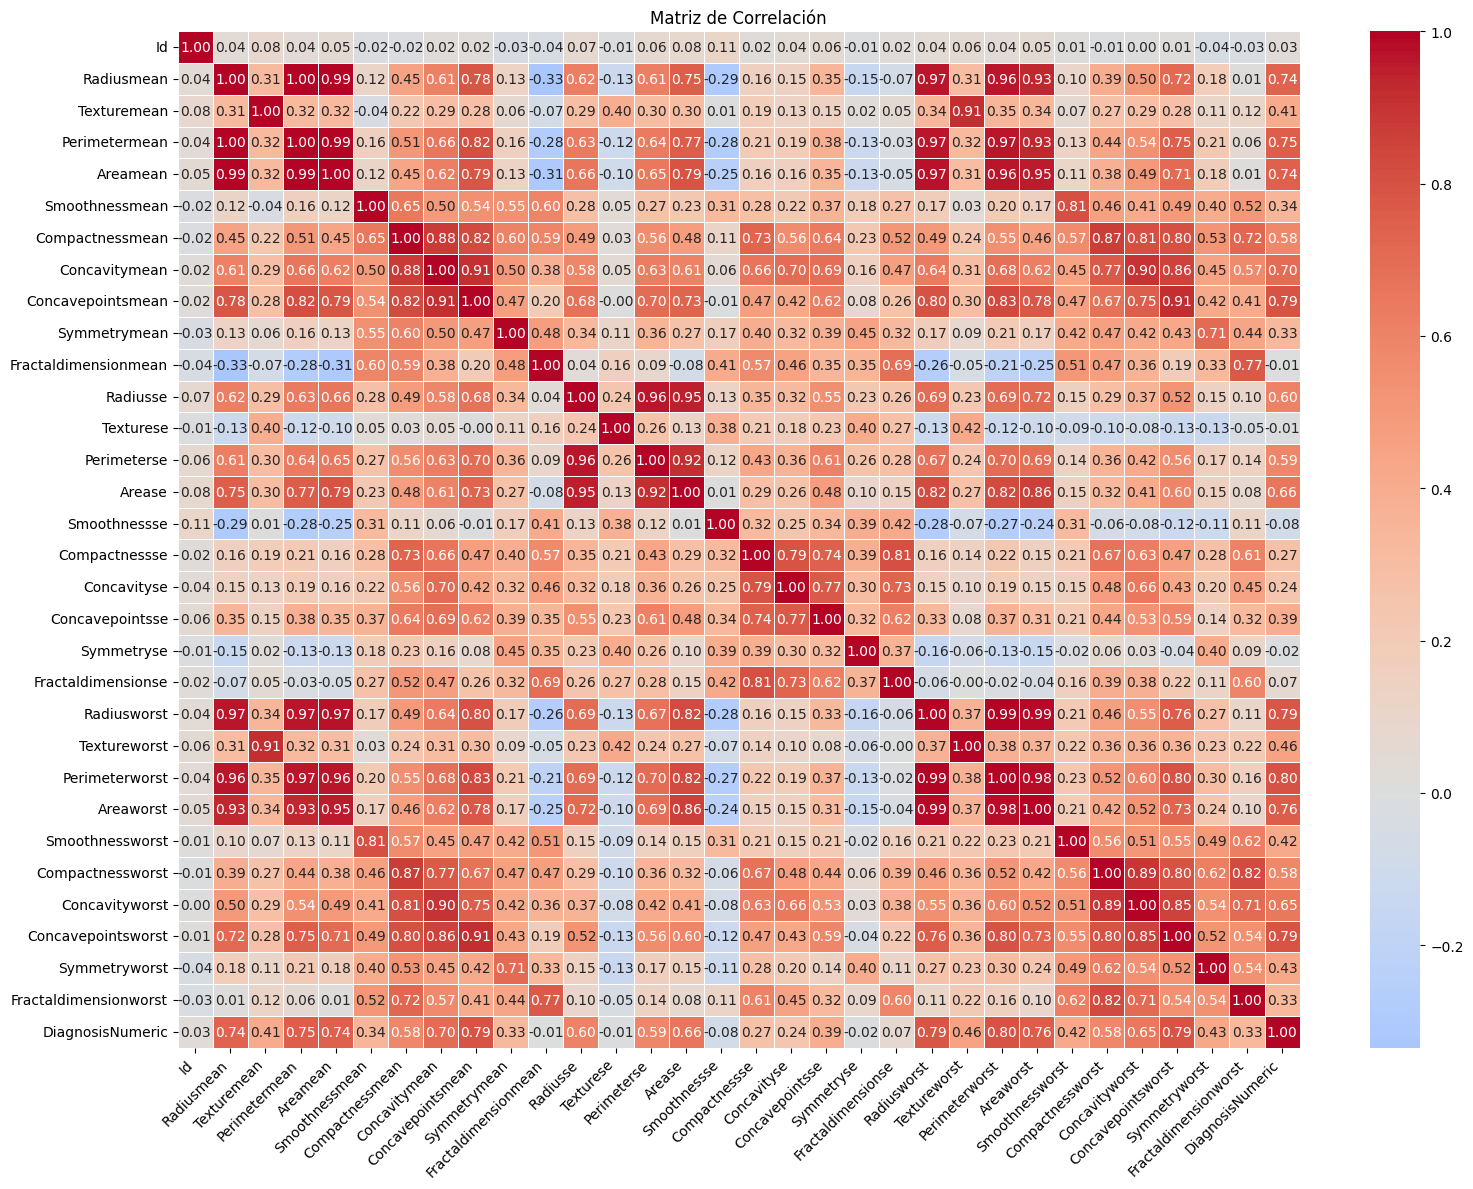

In [78]:
# 13. Matriz de correlación
corr_matrix = dfc.drop(columns=['Diagnosis']).corr()

# Heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, 
            annot=True,        # Muestra los valores numéricos
            fmt='.2f',         # 2 decimales
            cmap='coolwarm',   # Azul = correlación negativa, Rojo = positiva
            center=0,          # Centro de la escala en 0
            linewidths=0.5)    # Líneas entre celdas

plt.title('Matriz de Correlación')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()